# 01 NeuroVFM Features

Run official NeuroVFM preprocessing + frozen encoder on one MRI. Save token embeddings and coordinates for inspection.

In [1]:
from pathlib import Path
import sys

REPO = Path.cwd().resolve()
if not (REPO / 'src').exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))

from neuro_evidence.data import load_config, config_path
from neuro_evidence.encoder import NeuroVFMEncoder, save_token_batch, load_token_batch, sample_id_from_path
from neuro_evidence.pooling import coordinate_summary, mean_pool_tokens

cfg = load_config(REPO / 'configs' / 'baseline.yaml')
sample_mri = config_path(cfg, 'sample_mri')
outputs_dir = config_path(cfg, 'outputs_dir')
token_dir = outputs_dir / 'tokens'
token_dir.mkdir(parents=True, exist_ok=True)
cache_path = token_dir / f'{sample_id_from_path(sample_mri)}.npz'

print('sample_mri:', sample_mri)
print('cache_path:', cache_path)

sample_mri: /home/dev/NeuRL/../brainet/data/oasis/processed_mri/shared_n4_hdbet_crop/OAS30758_V01_I11215882.nii.gz
cache_path: /home/dev/NeuRL/outputs/tokens/OAS30758_V01_I11215882_c677e0dd.npz


In [2]:
# This cell can take a while on the first run. It uses the official NeuroVFM API.
if cache_path.exists():
    batch = load_token_batch(cache_path)
    print('loaded cache')
else:
    encoder = NeuroVFMEncoder(cfg)
    batch = encoder.extract(sample_mri)
    save_token_batch(batch, cache_path)
    print('saved cache')

print('raw NeuroVFM token input shape:', batch.input_shape)
print('embedding shape:', batch.embeddings.shape)
print('coords shape:', batch.coords.shape)
print('volume_size_dhw:', batch.volume_size_dhw)
print('patch_size:', batch.patch_size)
print('dense_grid_shape:', batch.dense_grid_shape)
print('dense_token_count:', batch.dense_token_count)
print('removed_background_count:', batch.removed_background_count)

loaded cache
raw NeuroVFM token input shape: [175, 1024]
embedding shape: (175, 768)
coords shape: (175, 3)
volume_size_dhw: [28, 160, 112]
patch_size: [4, 16, 16]
dense_grid_shape: (7, 10, 7)
dense_token_count: 490
removed_background_count: 315


In [3]:
coord_report = coordinate_summary(batch.coords, batch.dense_grid_shape)
coord_report

{'coord_min': [0, 0, 0],
 'coord_max': [6, 9, 6],
 'unique_coordinates': 175,
 'duplicate_coordinates': 0,
 'invalid_coordinates': 0,
 'dense_grid_shape': (7, 10, 7),
 'dense_token_count': 490,
 'missing_dense_coordinates': 315}

In [4]:
pooled = mean_pool_tokens(batch.embeddings)
print('mean pooled feature shape:', pooled.shape)
print('first 8 pooled values:', pooled[:8])

mean pooled feature shape: (768,)
first 8 pooled values: [-0.01083482 -0.03386077  0.00746052 -0.04690534 -0.03310651 -0.01067709
 -0.09501728  0.01284964]


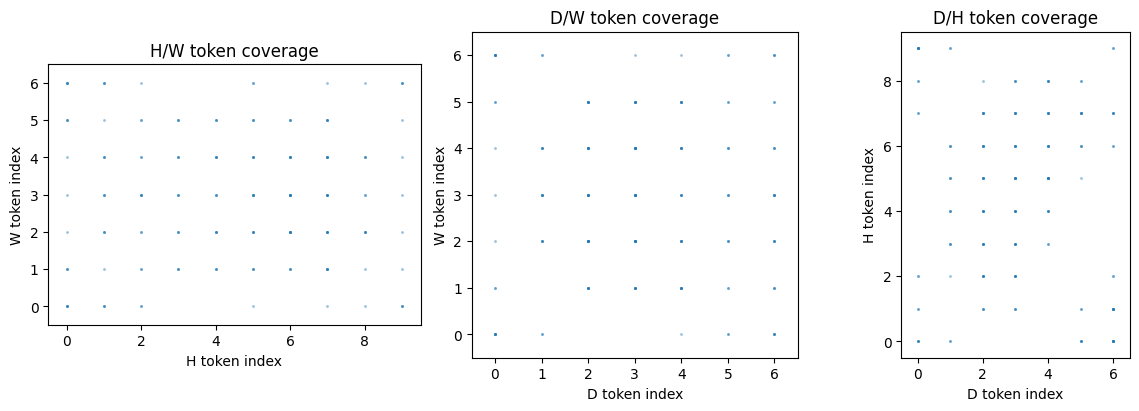

In [5]:
import matplotlib.pyplot as plt
import numpy as np

coords = batch.coords.astype(float)
grid = np.array(batch.dense_grid_shape, dtype=float)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
views = [
    (1, 2, 'H', 'W', 'H/W token coverage'),
    (0, 2, 'D', 'W', 'D/W token coverage'),
    (0, 1, 'D', 'H', 'D/H token coverage'),
]
for ax, (x_idx, y_idx, x_name, y_name, title) in zip(axes, views):
    ax.scatter(coords[:, x_idx], coords[:, y_idx], s=4, alpha=0.45, linewidths=0)
    ax.set_xlim(-0.5, max(grid[x_idx] - 0.5, 0.5))
    ax.set_ylim(-0.5, max(grid[y_idx] - 0.5, 0.5))
    ax.set_xlabel(f'{x_name} token index')
    ax.set_ylabel(f'{y_name} token index')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
plt.show()